In [32]:
import optuna
import optuna.visualization as vis
import pandas as pd
import pickle   
import matplotlib.pyplot as plt

In [33]:
results_classic = pd.read_csv('results/results_classical.csv')
results_xgboost = pd.read_csv('results/results_xgboost.csv')
results_mlp = pd.read_csv('results/results_MLP.csv')

In [34]:
# concat results 
results = pd.concat([results_classic, results_xgboost, results_mlp], ignore_index=True)

In [35]:
results.sort_values('mae', ascending=True, inplace=True)

In [36]:
results

,version,model,r2,mse,mae,best_params,validation_mae
62,stations_weights_linear,XGBRegressor,0.788898,30439.061746,101.321920,"{'n_estimators': 1100, 'learning_rate': 0.0157...",113.840505
59,stations_weights_inverse,XGBRegressor,0.790968,30140.569840,101.480831,"{'n_estimators': 700, 'learning_rate': 0.06032...",114.650424
60,stations_weights_gaussian,XGBRegressor,0.789009,30423.042082,101.933963,"{'n_estimators': 900, 'learning_rate': 0.06229...",114.377542
61,stations_weights_logarithmic,XGBRegressor,0.780932,31587.756342,102.276471,"{'n_estimators': 900, 'learning_rate': 0.03333...",114.277807
56,classic,XGBRegressor,0.783911,31158.080454,102.291392,"{'n_estimators': 800, 'learning_rate': 0.01513...",115.305035
...,...,...,...,...,...,...,...
53,stations_weights_linear,ElasticNet,0.457973,78155.570292,198.310488,"{'alpha': 0.1542428079533924, 'l1_ratio': 0.73...",214.674805
37,stations_weights_gaussian,ElasticNet,0.448668,79497.306395,199.709734,"{'alpha': 0.10520458340764034, 'l1_ratio': 0.6...",216.876220
45,stations_weights_logarithmic,ElasticNet,0.449721,79345.475640,200.101319,"{'alpha': 0.1010279683364219, 'l1_ratio': 0.45...",216.281156
29,stations_weights_inverse,ElasticNet,0.395338,87186.970696,210.639075,"{'alpha': 0.11320796430133717, 'l1_ratio': 0.2...",227.140987


In [37]:
results.to_csv('results/results.csv', index=False)

## Xgboost hyperparamaters

In [29]:
studies_xgboost = pickle.load(open('studies/studies_xgboost.pkl', 'rb'))
best_study_xgboost = studies_xgboost['stations_weights_linear_XGBRegressor']
best_study_xgboost.best_params

{'n_estimators': 1100,
 'learning_rate': 0.01576253164684871,
 'max_depth': 22,
 'min_child_weight': 4,
 'subsample': 0.5051200702138716,
 'colsample_bytree': 0.6569239664184245,
 'reg_alpha': 0.12392462946123958,
 'reg_lambda': 7.481477787444512}

/tmp/ipykernel_283274/2944987438.py:1: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis.matplotlib.plot_optimization_history(best_study_xgboost)


TypeError: title() missing 1 required positional argument: 'label'

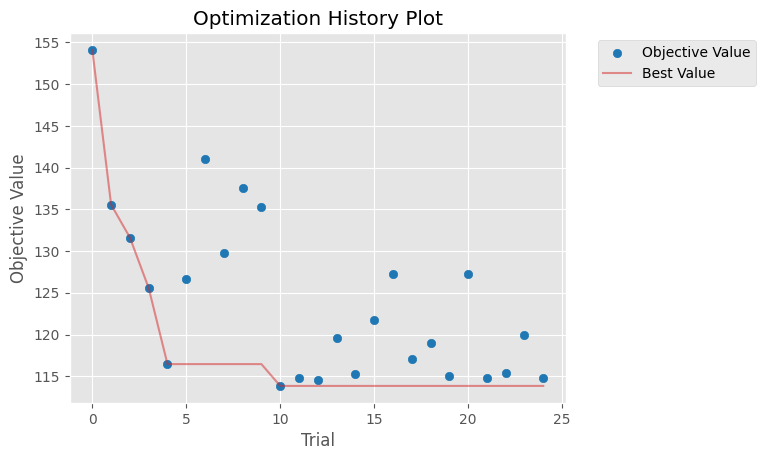

In [31]:


vis.matplotlib.plot_optimization_history(best_study_xgboost)
plt.title()
plt.show()

/tmp/ipykernel_283274/1305444920.py:1: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis.matplotlib.plot_param_importances(best_study_xgboost)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

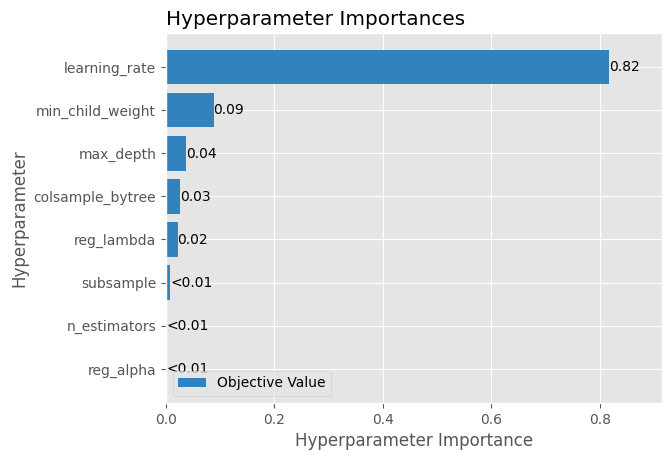

In [27]:
vis.matplotlib.plot_param_importances(best_study_xgboost)


/tmp/ipykernel_283274/1341360852.py:1: ExperimentalWarning: plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  vis.matplotlib.plot_contour(best_study_xgboost, params=["learning_rate", "min_child_weight"])
[W 2024-04-25 19:54:05,397] Output figures of this Matplotlib-based `plot_contour` function would be different from those of the Plotly-based `plot_contour`.


<Axes: title={'center': 'Contour Plot'}, xlabel='learning_rate', ylabel='min_child_weight'>

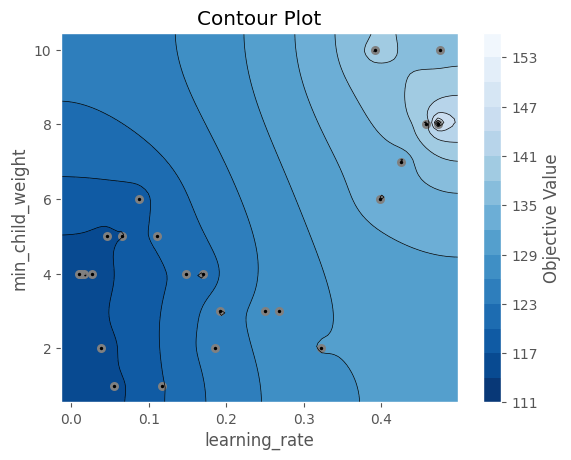

In [28]:
vis.matplotlib.plot_contour(best_study_xgboost, params=["learning_rate", "min_child_weight"])

In [ ]:
# Xgbooost feature importance